# Tile Inference with foundation models

In this notebook, we will do two things:
  1. Load a series of tiles (not whole slides)
  2. Do inference on using a Triton-hosted model

Optionally, you can also run the bottom cells to:
   3. Visualize inference results using UMAP
   4. Write inference results to a zarr file


## Import needed libraries
Our Docker container has all the needed libraries.
If you want to run this notebook locally, you can install all the dependencies with:
`pip3 install --no-cache-dir torch torchvision --index-url https://download.pytorch.org/whl/cpu && pip install .[examples]`
from the root directory of the repository.

In [1]:
import glob
import os

# hide the GPU from TensorFlow - tritonserver will use it, not us
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

from jupyter_core.utils import ensure_dir_exists
from medmnist import BloodMNIST
from monai.data import DataLoader, Dataset
from monai.utils import CommonKeys
import monai.transforms as mt
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

from simple_triton.feature_extraction import inference
from simple_triton.utils import analyze
from simple_triton.model import TritonModel

<frozen importlib._bootstrap_external>:1184: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-03-04 13:33:50.730401: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Item 1: Load an example dataset of _tiles_
We use the BloodMNIST dataset. This is a public archive of labeled images that you can store as PNG or JPG in different sizes.
In the code below, we save the first `num_images_in_example` images to a local directory as PNG files. We will use these images for inference.

BloomMNIST is from MedMNIST, which is a dataset published in the following papers:
Jiancheng Yang, Rui Shi, Donglai Wei, Zequan Liu, Lin Zhao, Bilian Ke, Hanspeter Pfister, Bingbing Ni. Yang, Jiancheng, et al. "MedMNIST v2-A large-scale lightweight benchmark for 2D and 3D biomedical image classification." Scientific Data, 2023.
Jiancheng Yang, Rui Shi, Bingbing Ni. "MedMNIST Classification Decathlon: A Lightweight AutoML Benchmark for Medical Image Analysis". IEEE 18th International Symposium on Biomedical Imaging (ISBI), 2021.

100%|██████████| 1.54G/1.54G [00:51<00:00, 29.8MB/s]


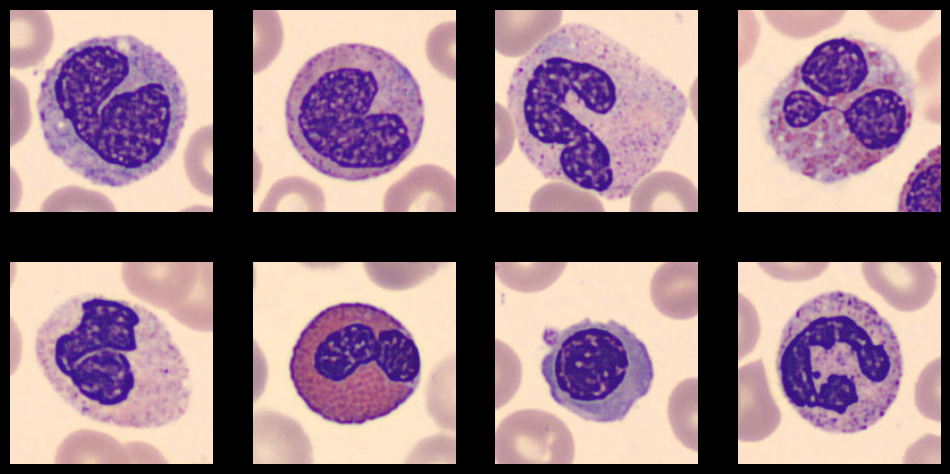

In [2]:
mnist_root="./mnist_data"
ensure_dir_exists(mnist_root)
test_dataset = BloodMNIST(split="test", root="./mnist_data", download=True, size=224)

data_dir = "./examples_inference_images/"
# create a directory called "examples_inference_images" in the current directory to save some images
os.makedirs(data_dir, exist_ok=True)
num_images_in_example = 1000
labels = []
for i in range(num_images_in_example):
    img, label = test_dataset[i]
    img_dst = f"examples_inference_images/{i}.png"
    if not os.path.exists(img_dst):
        img.save(img_dst)
    labels.append(label[0])

files = glob.glob(f"{data_dir}{os.sep}**/*.png", recursive=True)
assert len(files), f"no files found in {data_dir}"

# show eight of the images in a grid
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axs.flat):
    ax.imshow(plt.imread(files[i]))
    ax.axis("off")
plt.show()

## Associate labels and metadata with each image

In [3]:
all_data = []
for filename, label in zip(files, labels):
    # CommonKeys is just a string enum
    all_data.append({CommonKeys.IMAGE: filename,
                     CommonKeys.LABEL: label,
                     "filename": filename,
                     # if you have more information per image, you can add it here, such as tile_position, patient age, etc.
                     })

## Create a dataloader compatible with simple_triton
In this code, we use MONAI, which is a wrapper around PyTorch. I like to use MONAI since:
   * they have many common image transform functions
   * Their dataloader is easy to use.

You do not have use MONAI. The only important thing is to have an iterator that returns (sample, metadata) pairs.

In [4]:
transformations = mt.Compose(
    [
        mt.LoadImaged(CommonKeys.IMAGE, image_only=True),
        mt.EnsureTyped(CommonKeys.IMAGE),
        mt.ToNumpyD(keys=CommonKeys.IMAGE, dtype=np.uint8),
    ])

def triton_collate_fn(batch):
    '''
    collate function for simple_triton inference.
    This function changes the MONAI dataloader to return (sample, metadata)
    instead of a dictionary, which is the default behaviour.
    '''
    images = np.array([item[CommonKeys.IMAGE] for item in batch])
    meta = [{k:v for (k,v) in item.items() if k != CommonKeys.IMAGE} for item in batch]
    return images, meta

dl = DataLoader(dataset=Dataset(all_data, transformations), batch_size=32, shuffle=False, collate_fn=triton_collate_fn)


# Item 2: Inference on triton
We start by loading a model from Triton.
Then, we do inference by sending tiles via this client.

For "uni" model, I started tritonserver with this command, executed from the root directory of the repository:
```bash
docker build -t model-tritonserver -f server.Dockerfile .
# your huggingface token. You also need access on the "uni" repository:
# https://huggingface.co/MahmoodLab/UNI
export HF_TOKEN=...
docker run --name tritonserver_$USER -e HF_TOKEN=$HF_TOKEN  --gpus all --rm -p 8001:8001 --shm-size=1g --ulimit memlock=-1 --ipc=host -v ${PWD}/models:/models model-tritonserver:latest tritonserver --model-repository=/models --model-control-mode=explicit --exit-on-error=false --strict-model-config=false --load-model uni --backend-config=default-max-batch-size=32 --metrics-config summary_latencies=true
```

In [6]:
model_name = "uni" # or use any other that model in the "models" directory
url = "localhost:8001/"

model = TritonModel(model_name, url)
model.load()
assert model.is_loaded()
pprint(model.get_config())

{'backend': 'python',
 'defaultModelFilename': 'model.py',
 'input': [{'dataType': 'TYPE_UINT8',
            'dims': ['3', '224', '224'],
            'name': 'input_0'}],
 'instanceGroup': [{'count': 1, 'kind': 'KIND_CPU', 'name': 'resnet50'}],
 'maxBatchSize': 256,
 'name': 'resnet50',
 'optimization': {'inputPinnedMemory': {'enable': True},
                  'outputPinnedMemory': {'enable': True}},
 'output': [{'dataType': 'TYPE_FP32', 'dims': ['1000'], 'name': 'output_0'}],
 'versionPolicy': {'latest': {'numVersions': 1}}}


## Start inference

In [8]:
features, tile_info, times = inference(
    iter(dl),
    model_name,
    url=url,
    limit=1,
)
analyze(times)

print(f"Inference done. Output has shape: {features.shape}")

KeyboardInterrupt: 

## Optional: inference in batches
if you have a lot of data, you can also run the inference in batches in case you'll run out of memory

In [20]:
# the next line prevents this cell from running automatically, since the cell does the same as the code above just in batches instead of doing all at once
if False:
    for batch in dl:
        features, tile_info, times = inference(
           iter([(batch[0], batch[1])]),
           model_name,
           source=None,
           target=None,
           url=url,
           limit=1,
        )
        analyze(times)

        print(f"Inference done. Output has shape: {features.shape}")

# Optional step 3: visualize the results

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.


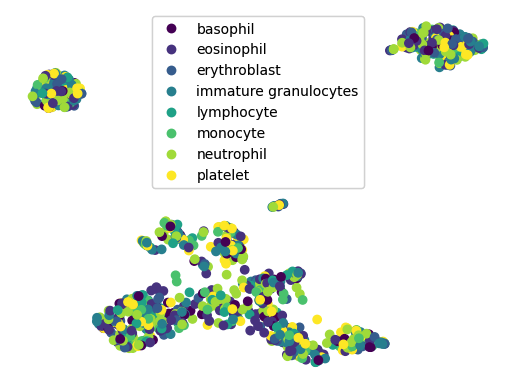

In [16]:
from umap import UMAP
from medmnist.info import INFO

label_map = INFO["bloodmnist"]["label"]
# shorten the labels so that they fit into the legend
label_map = {int(k): v.split("(")[0] for k, v in label_map.items()}

umap = UMAP(n_components=2)
umap_features = umap.fit_transform(features)
fig, ax = plt.subplots()

scatter = plt.scatter(umap_features[:, 0], umap_features[:, 1],
            c=tile_info[CommonKeys.LABEL], cmap='viridis')

handles = scatter.legend_elements(num=range(len(list(label_map.values()))))[0]
legend1 = ax.legend(handles=handles, labels=label_map.values())
ax.add_artist(legend1)

plt.axis('off')
plt.show()

# Optional step 4: write the results to a zarr file
This allows you to retrieve the embeddings later without having to re-run the inference.

In [12]:
import numcodecs

import zarr.storage
root = zarr.group()
for fname,l,f in zip(tile_info['filename'], tile_info[CommonKeys.LABEL], features):
    dataset = root.create_dataset(
        fname.lstrip("./"),
        data=f,
        compressor=numcodecs.Blosc(cname='zstd', clevel=3, shuffle=numcodecs.Blosc.AUTOSHUFFLE)
    )
    # Set attributes on the dataset if you want to
    dataset.attrs[CommonKeys.LABEL] = l

dst_pth="./example.zarr.zip"
# this code will not work if dst_pth already exists - delete it first
# or use the following code:
#import shutil; shutil.rmtree(dst_pth, ignore_errors=True)
dir_store = zarr.storage.ZipStore(dst_pth)
n_copied, n_skipped, n_bytes_copied = zarr.copy_store(root.store, dir_store)
print(f"Wrote zarr embeddings to {dst_pth}")

Wrote zarr embeddings to ./example.zarr.zip
